In [2]:
!pip install adjustText

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [4]:
df = pd.read_csv('../data/raw/nba_pergame_2526.csv')
df.head()

,Rk,Player,Age,Team,Pos,G,GS,MP,FG,FGA,...,DRB,TRB,AST,STL,BLK,TOV,PF,PTS,Awards,Player-additional
0,1.0,Luka Dončić,26.0,LAL,PG,64.0,64.0,35.8,10.8,22.8,...,7.1,7.7,8.3,1.6,0.5,4.0,2.4,33.5,MVP-4CPOY-8ASNBA1,doncilu01
1,2.0,Shai Gilgeous-Alexander,27.0,OKC,PG,68.0,68.0,33.2,10.8,19.4,...,3.7,4.3,6.6,1.4,0.8,2.2,2.0,31.1,MVP-1CPOY-1ASNBA1,gilgesh01
2,3.0,Anthony Edwards,24.0,MIN,SG,61.0,60.0,35.0,9.9,20.2,...,4.4,5.0,3.7,1.4,0.8,2.9,1.9,28.8,CPOY-3AS,edwaran01
3,4.0,Jaylen Brown,29.0,BOS,SF,71.0,71.0,34.4,10.4,21.7,...,5.8,6.9,5.1,1.0,0.4,3.6,2.7,28.7,MVP-6ASNBA2,brownja02
4,5.0,Tyrese Maxey,25.0,PHI,PG,70.0,70.0,38.0,9.9,21.4,...,3.8,4.1,6.6,1.9,0.8,2.4,2.2,28.3,CPOY-7ASNBA3,maxeyty01


Data Overview

In [ ]:
print(df.shape)
print(df.columns.tolist())
print(df.isnull().sum())

(734, 32)
['Rk', 'Player', 'Age', 'Team', 'Pos', 'G', 'GS', 'MP', 'FG', 'FGA', 'FG%', '3P', '3PA', '3P%', '2P', '2PA', '2P%', 'eFG%', 'FT', 'FTA', 'FT%', 'ORB', 'DRB', 'TRB', 'AST', 'STL', 'BLK', 'TOV', 'PF', 'PTS', 'Awards', 'Player-additional']
Rk                     1
Player                 0
Age                    1
Team                   1
Pos                    1
G                      1
GS                     1
MP                     1
FG                     1
FGA                    1
FG%                    3
3P                     1
3PA                    1
3P%                   51
2P                     1
2PA                    1
2P%                    7
eFG%                   3
FT                     1
FTA                    1
FT%                   31
ORB                    1
DRB                    1
TRB                    1
AST                    1
STL                    1
BLK                    1
TOV                    1
PF                     1
PTS                    1
Awa

## Data Cleaning
Removes duplicate player entries created by mid-season trades. 
For players traded during the season, Basketball Reference lists 
separate rows for each team plus a combined "2TM" row. We keep 
only the combined row to avoid counting players twice.

In [5]:
df_clean = df[~df.duplicated(subset='Player', keep=False) | df['Team'].isin(['2TM', '3TM', '4TM'])]

## Player Selection Filter
Filters the dataset to elite guards and wings only using four criteria:
- **Position**: PG, SG, SF only (excludes big men)
- **Minutes per game**: 28+ (ensures meaningful playing time)
- **Points per game**: 15+ (ensures primary scoring role)
- **Games played**: 50+ (ensures sufficient sample size)

This produces a final dataset of 43 elite guards and wings.

In [6]:
df_stars = df_clean[df_clean['Pos'].isin(['PG', 'SG', 'SF']) & (df_clean['MP'] > 28) & (df_clean['PTS'] > 15) & (df_clean['GS'] >= 50)].copy()

## True Shooting Percentage (TS%)
Calculates True Shooting Percentage for each player using the formula:

**TS% = PTS / (2 x (FGA + 0.44 x FTA))**

TS% accounts for two-point field goals, three-point field goals, and free throws 
in a single efficiency number. The 0.44 multiplier approximates that a free throw 
trip uses roughly half a possession.

In [7]:
df_stars['TS%'] = df_stars['PTS'] / (2 * (df_stars['FGA'] + 0.44 * df_stars['FTA']))

## Visualization 1: Quadrant Analysis
Scatter plot dividing players into four quadrants based on their 
PPG and TS% relative to the group average:

- **True Elite**: High PPG + High TS%
- **Volume Scorers**: High PPG + Low TS%
- **Hidden Gems**: Low PPG + High TS%
- **Inefficient**: Low PPG + Low TS%

Dividing lines represent the group average for both metrics.

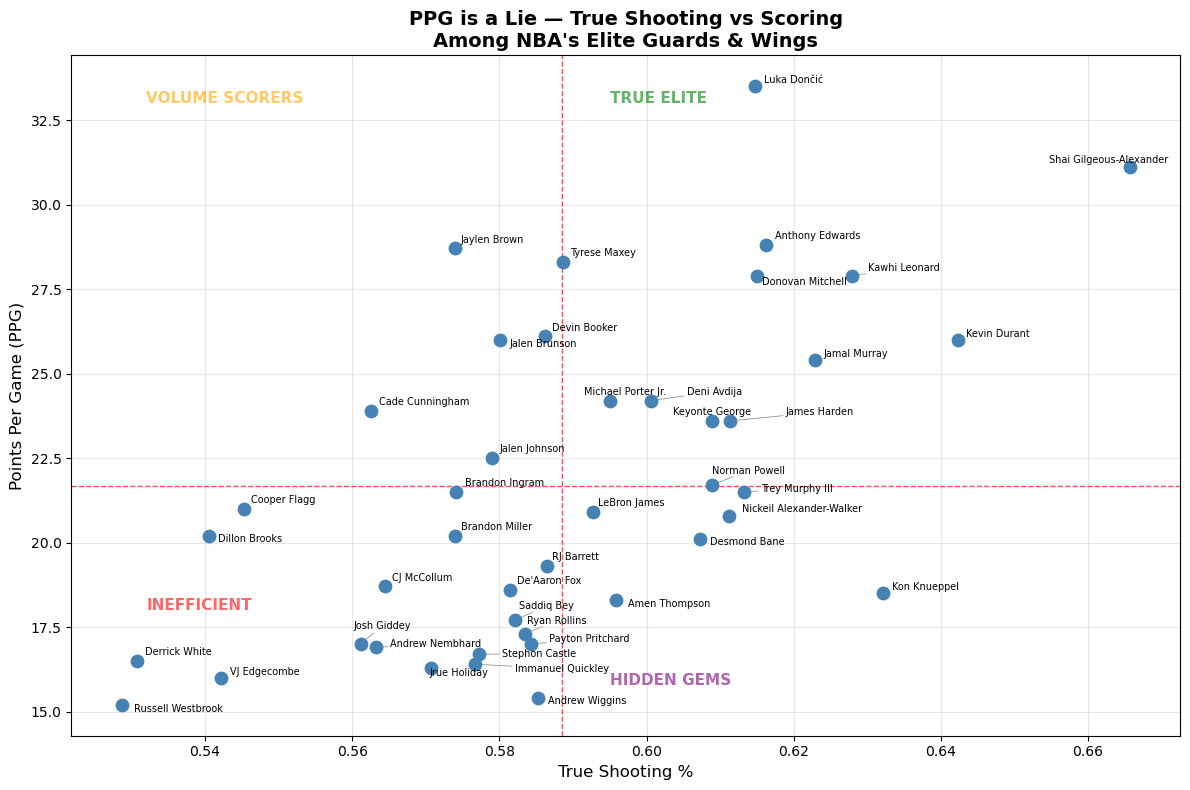

In [8]:
fig, ax = plt.subplots(figsize=(12, 8))

ax.scatter(df_stars['TS%'], df_stars['PTS'], color='steelblue', s=80, zorder=3)

# quadrant lines
ax.axvline(x=0.588476, color='red', linestyle='--', linewidth=1, alpha=0.7)
ax.axhline(y=21.660465, color='red', linestyle='--', linewidth=1, alpha=0.7)

# quadrant labels
ax.text(0.595, 33, 'TRUE ELITE', fontsize=11, fontweight='bold', color='green', alpha=0.6)
ax.text(0.532, 33, 'VOLUME SCORERS', fontsize=11, fontweight='bold', color='orange', alpha=0.6)
ax.text(0.595, 15.8, 'HIDDEN GEMS', fontsize=11, fontweight='bold', color='purple', alpha=0.6)
ax.text(0.532, 18, 'INEFFICIENT', fontsize=11, fontweight='bold', color='red', alpha=0.6)

# labels and title
ax.set_xlabel('True Shooting %', fontsize=12)
ax.set_ylabel('Points Per Game (PPG)', fontsize=12)
ax.set_title("PPG is a Lie — True Shooting vs Scoring\nAmong NBA's Elite Guards & Wings", fontsize=14, fontweight='bold')

ax.grid(True, alpha=0.3)

# label all players with adjustText
from adjustText import adjust_text

texts = []
for _, row in df_stars.iterrows():
    texts.append(ax.text(row['TS%'], row['PTS'], row['Player'], fontsize=7))

adjust_text(texts, ax=ax, arrowprops=dict(arrowstyle='-', color='gray', lw=0.5))

plt.tight_layout()
plt.savefig('../visuals/quadrant_chart.png', dpi=300, bbox_inches='tight')
plt.show()

## Regression & Residual Calculation
Fits a regression line to the TS% vs PPG data and calculates 
residuals for each player. Residuals measure how far each player 
deviates from the expected PPG given their TS%, used to identify 
outliers in the quadrant chart.

In [9]:
# fit a regression line
m, b = np.polyfit(df_stars['TS%'], df_stars['PTS'], 1)

# calculate predicted PTS for each player
df_stars['predicted_PTS'] = m * df_stars['TS%'] + b

# calculate residuals
df_stars['residual'] = df_stars['PTS'] - df_stars['predicted_PTS']

## Rank Gap Calculation
Ranks all 43 players by PPG and TS% separately, then calculates 
the gap between the two rankings. A positive gap means the player 
ranks higher in PPG than TS% (overrated by scoring). A negative 
gap means they rank higher in TS% than PPG (underrated by scoring).

In [10]:
df_stars['PPG_rank'] = df_stars['PTS'].rank(ascending=False)
df_stars['TS%_rank'] = df_stars['TS%'].rank(ascending=False)
df_stars['rank_gap'] = df_stars['PPG_rank'] - df_stars['TS%_rank']

## Visualization 2: PPG Rank vs TS% Rank Gap
Horizontal bar chart showing the difference between each player's 
PPG rank and TS% rank among the 43 stars.

- **Green bars**: Player ranks higher in TS% than PPG (more efficient than they appear)
- **Red bars**: Player ranks higher in PPG than TS% (less efficient than they appear)

The larger the bar, the bigger the gap between perception and reality.

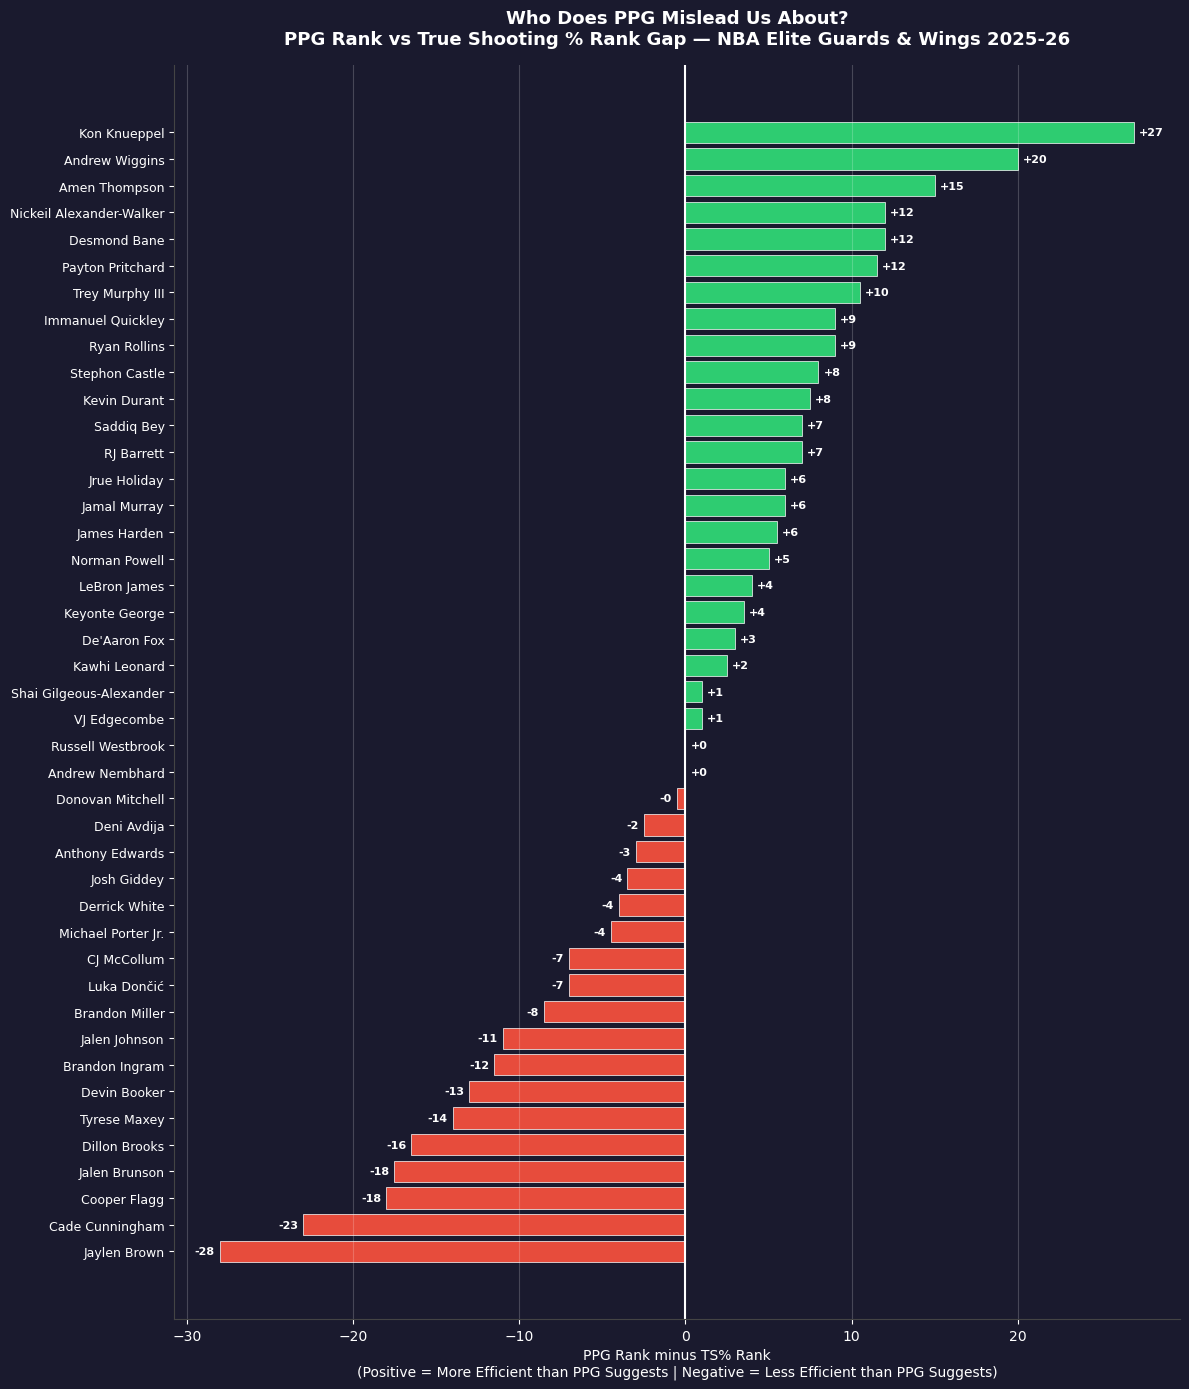

In [112]:
# sort by rank gap
df_plot = df_stars[['Player', 'rank_gap']].sort_values('rank_gap', ascending=True)

# color bars based on positive/negative
colors = ['#2ecc71' if x >= 0 else '#e74c3c' for x in df_plot['rank_gap']]

fig, ax = plt.subplots(figsize=(12, 14))

bars = ax.barh(df_plot['Player'], df_plot['rank_gap'], color=colors, edgecolor='white', linewidth=0.5)

# add value labels on bars
for bar, val in zip(bars, df_plot['rank_gap']):
    ax.text(val + (0.3 if val >= 0 else -0.3), 
            bar.get_y() + bar.get_height()/2,
            f'{val:+.0f}',
            va='center',
            ha='left' if val >= 0 else 'right',
            fontsize=8,
            fontweight='bold',
            color = 'white')

# reference line
ax.axvline(x=0, color='white', linewidth=1.5)

# styling
ax.set_facecolor('#1a1a2e')
fig.patch.set_facecolor('#1a1a2e')
ax.tick_params(colors='white')
ax.xaxis.label.set_color('white')
ax.title.set_color('white')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#444')
ax.spines['bottom'].set_color('#444')

ax.set_xlabel('PPG Rank minus TS% Rank\n(Positive = More Efficient than PPG Suggests | Negative = Less Efficient than PPG Suggests)', 
              fontsize=10, color='white')
ax.set_title('Who Does PPG Mislead Us About?\nPPG Rank vs True Shooting % Rank Gap — NBA Elite Guards & Wings 2025-26', 
             fontsize=13, fontweight='bold', color='white', pad=15)

ax.tick_params(axis='y', labelsize=9, colors='white')
ax.tick_params(axis='x', colors='white')
ax.grid(axis='x', alpha=0.2, color='white')

plt.tight_layout()
plt.savefig('../visuals/rank_gap_chart.png', dpi=300, bbox_inches='tight', facecolor='#1a1a2e')
plt.show()